In [1]:
!pip install pandas openpyxl sqlalchemy pymysql


In [2]:
import pandas as pd
from sqlalchemy import create_engine
import urllib.parse

# 1. File and credentials
excel_file = 'frido_sales_analysis_dataset_updated.xlsx'

db_user = 'root'
db_password = 'air@32568'  # Your password with @
db_host = '127.0.0.1'
db_port = '3306'
db_name = 'frido_home_appliances_sales'

# 2. Encode the password (turns @ into %40)
safe_password = urllib.parse.quote_plus(db_password)

# 3. Create database connection
engine = create_engine(f'mysql+pymysql://{db_user}:{safe_password}@{db_host}:{db_port}/{db_name}')

# 4. Read all sheets and upload each to MySQL automatically
all_sheets = pd.read_excel(excel_file, sheet_name=None)

for sheet_name, df in all_sheets.items():
    table_name = sheet_name.strip().lower().replace(" ", "_")
    df.to_sql(table_name, con=engine, if_exists='replace', index=False)
    print(f"Successfully loaded sheet '{sheet_name}' as table '{table_name}'")

Successfully loaded sheet 'Product_Master' as table 'product_master'
Successfully loaded sheet 'Vendor_Master' as table 'vendor_master'
Successfully loaded sheet 'Customer_Master' as table 'customer_master'
Successfully loaded sheet 'Date_Table' as table 'date_table'
Successfully loaded sheet 'Sales_Transactions' as table 'sales_transactions'
Successfully loaded sheet 'Inventory' as table 'inventory'


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_theme(style="whitegrid")


# Frido Home Appliances — Sales & Profitability Analysis
### Executive Summary & SQL Queries
---

1. Overall Category Performance

In [4]:
import warnings
warnings.filterwarnings("ignore")

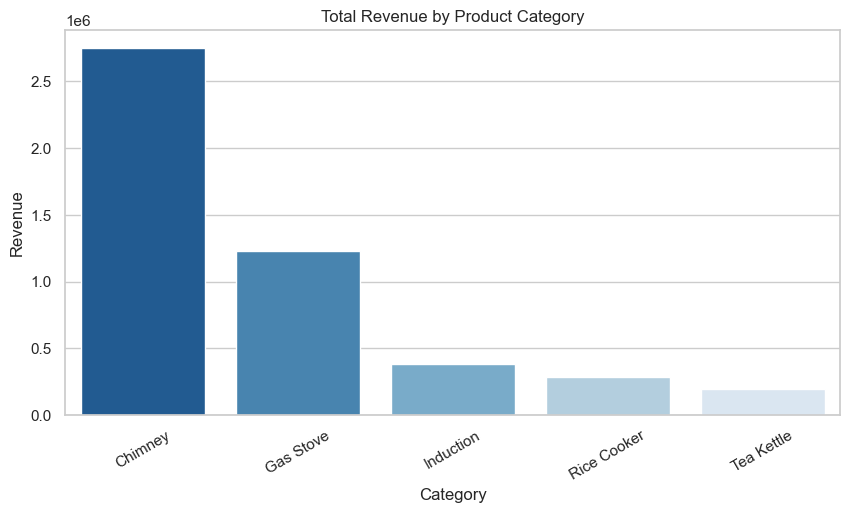

In [5]:
query_1 = """
SELECT Category, SUM(Net_Sales) AS Revenue, SUM(Profit) AS Profit
FROM sales_transactions
GROUP BY Category ORDER BY Revenue DESC;
"""
df1 = pd.read_sql(query_1, con=engine)

plt.figure(figsize=(10, 5))
sns.barplot(data=df1, x='Category', y='Revenue', palette='Blues_r')
plt.title('Total Revenue by Product Category')
plt.xticks(rotation=30)
plt.show()

2. Profit margin by subcategory

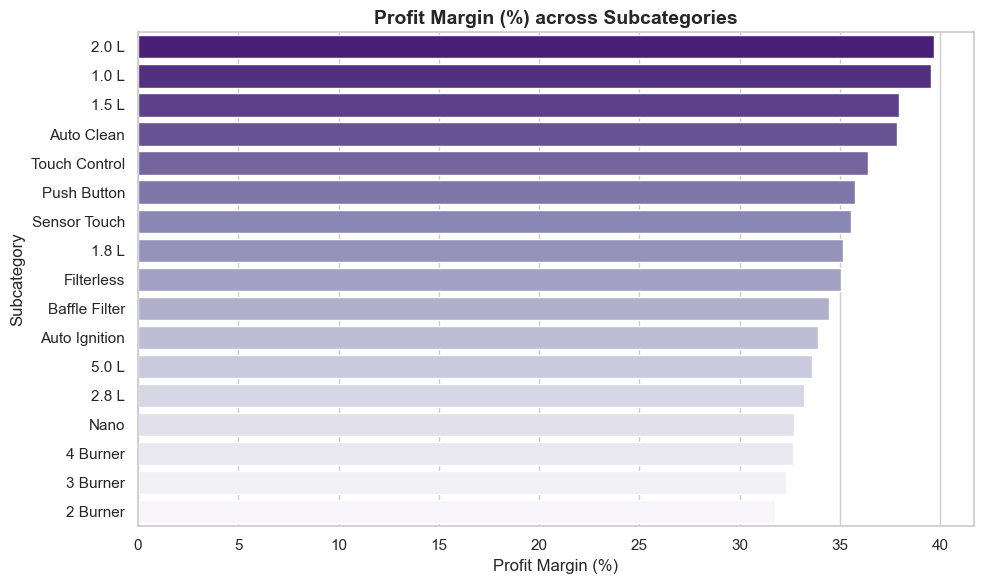

In [6]:


query_4 = """
SELECT 
    p.Subcategory, 
    ROUND(SUM(s.Profit) / SUM(s.Net_Sales) * 100, 2) AS Profit_Margin
FROM sales_transactions s
JOIN product_master p ON s.Product_ID = p.Product_ID
GROUP BY p.Subcategory 
ORDER BY Profit_Margin DESC;
"""

df4 = pd.read_sql(query_4, con=engine)

plt.figure(figsize=(10, 6))
sns.barplot(data=df4, x='Profit_Margin', y='Subcategory', palette='Purples_r')
plt.title('Profit Margin (%) across Subcategories', fontsize=14, fontweight='bold')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Subcategory')
plt.tight_layout()
plt.show()

3. Sales distribution by day of the week

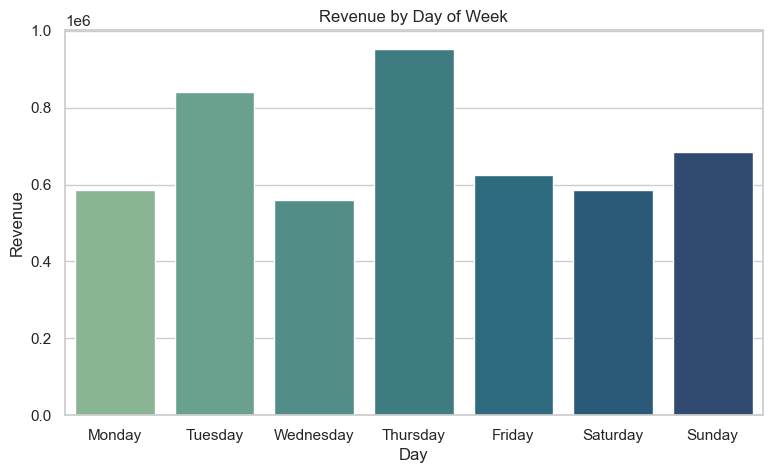

In [7]:
query_3 = """
SELECT DAYNAME(Order_Date) AS Day, SUM(Net_Sales) AS Revenue
FROM sales_transactions
GROUP BY Day ORDER BY FIELD(Day, 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday');
"""
df11 = pd.read_sql(query_3, con=engine)

plt.figure(figsize=(9, 5))
sns.barplot(data=df11, x='Day', y='Revenue', palette='crest')
plt.title('Revenue by Day of Week')
plt.show()

4. Repeat Vs First time orders

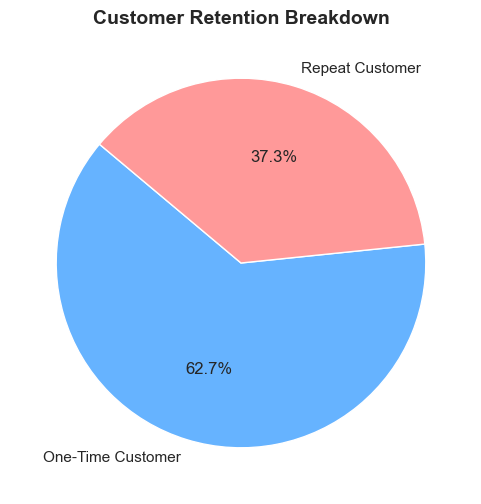

In [8]:
query_4 = """
SELECT 
    CASE 
        WHEN total_orders > 1 THEN 'Repeat Customer' 
        ELSE 'One-Time Customer' 
    END AS Customer_Status,
    COUNT(Customer_ID) AS Total_Customers
FROM (
    SELECT 
        Customer_ID, 
        COUNT(*) AS total_orders
    FROM sales_transactions 
    GROUP BY Customer_ID
) AS customer_orders
GROUP BY Customer_Status;
"""

df10 = pd.read_sql(query_4, con=engine)

plt.figure(figsize=(6, 6))
plt.pie(
    df10['Total_Customers'], 
    labels=df10['Customer_Status'], 
    autopct='%1.1f%%', 
    colors=['#66b3ff', '#ff9999'],
    startangle=140
)
plt.title('Customer Retention Breakdown', fontsize=14, fontweight='bold')
plt.show()

5. Discount Impact on sales

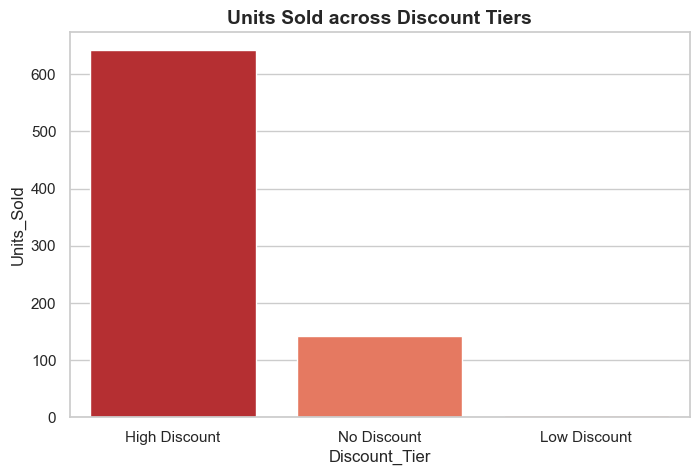

In [9]:
query_5 = """
SELECT 
    CASE 
        WHEN Discount_Amount = 0 OR Discount_Amount IS NULL THEN 'No Discount'
        WHEN Discount_Amount > 0 AND Discount_Amount <= 50 THEN 'Low Discount'
        ELSE 'High Discount'
    END AS Discount_Tier,
    COUNT(*) AS Total_Orders,
    SUM(Quantity) AS Units_Sold
FROM sales_transactions
GROUP BY Discount_Tier
ORDER BY Units_Sold DESC;
"""

df9 = pd.read_sql(query_5, con=engine)

plt.figure(figsize=(8, 5))
sns.barplot(data=df9, x='Discount_Tier', y='Units_Sold', palette='Reds_r')
plt.title('Units Sold across Discount Tiers', fontsize=14, fontweight='bold')
plt.show()

#SOME QUESTIONS ON THE BASIS OF THIS ANALYSIS !!

1. Which product categories are driving frido home appliances's revenue?


In [10]:
query = """
SELECT
    Category,
    SUM(Net_Sales) AS Revenue,
    SUM(Profit) AS Profit,
    ROUND(SUM(Profit) / SUM(Net_Sales) * 100, 2) AS Profit_Margin
FROM sales_transactions
GROUP BY Category
ORDER BY Revenue DESC;
"""

category_analysis = pd.read_sql(query, con=engine)
category_analysis

,Category,Revenue,Profit,Profit_Margin
0,Chimney,2747414.10,992514.10,36.13
1,Gas Stove,1228179.68,403529.68,32.86
2,Induction,381374.63,137174.63,35.97
3,Rice Cooker,284038.56,96088.56,33.83
4,Tea Kettle,192001.15,74871.15,39.00


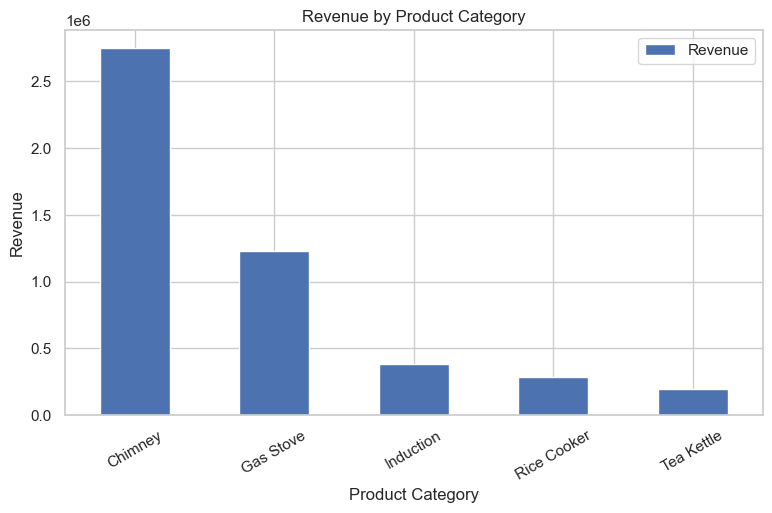

In [11]:
category_analysis.plot(
    x="Category",
    y="Revenue",
    kind="bar",
    figsize=(9,5),
    title="Revenue by Product Category"
)

plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.show()


2. Which categories are profitable, not just high selling?

In [12]:
query = """
SELECT
    Category,
    SUM(Net_Sales) AS Revenue,
    SUM(Profit) AS Total_Profit,
    ROUND(SUM(Profit) / SUM(Net_Sales) * 100, 2) AS Profit_Margin
FROM Sales_Transactions
GROUP BY Category
ORDER BY Total_Profit DESC;
"""

profit_analysis = pd.read_sql(query, con=engine)
profit_analysis

,Category,Revenue,Total_Profit,Profit_Margin
0,Chimney,2747414.10,992514.10,36.13
1,Gas Stove,1228179.68,403529.68,32.86
2,Induction,381374.63,137174.63,35.97
3,Rice Cooker,284038.56,96088.56,33.83
4,Tea Kettle,192001.15,74871.15,39.00


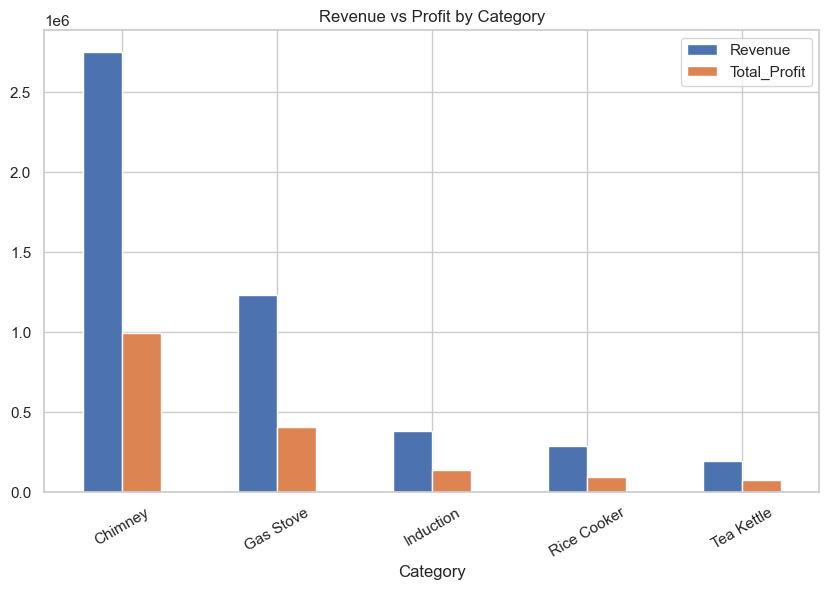

In [13]:
profit_analysis.plot(
    x="Category",
    y=["Revenue", "Total_Profit"],
    kind="bar",
    figsize=(10,6),
    title="Revenue vs Profit by Category"
)

plt.xticks(rotation=30)
plt.show()

3.  How is sales analysis changing month by month?

In [14]:
query = """
SELECT
    MONTH(Order_Date) AS Month_Number,
    MONTHNAME(Order_Date) AS Month,
    SUM(Net_Sales) AS Revenue,
    SUM(Profit) AS Profit,
    SUM(Quantity) AS Units_Sold
FROM Sales_Transactions
GROUP BY
    MONTH(Order_Date),
    MONTHNAME(Order_Date)
ORDER BY Month_Number;
"""

monthly_analysis = pd.read_sql(query, con=engine)
monthly_analysis

,Month_Number,Month,Revenue,Profit,Units_Sold
0,1,January,882071.71,311321.71,134.0
1,2,February,707393.10,252353.10,96.0
2,3,March,906807.81,316207.81,149.0
3,4,April,605230.42,211080.42,137.0
4,5,May,900229.24,324539.24,123.0
5,6,June,831275.84,288675.84,147.0


4. Which sates are generating the most revenue?

In [15]:
query = """
SELECT
    c.State,
    SUM(s.Net_Sales) AS Revenue,
    SUM(s.Profit) AS Profit,
    SUM(s.Quantity) AS Units_Sold
FROM Sales_Transactions s
JOIN Customer_Master c
    ON s.Customer_ID = c.Customer_ID
GROUP BY c.State
ORDER BY Revenue DESC;
"""

state_analysis = pd.read_sql(query, con=engine)
state_analysis

,State,Revenue,Profit,Units_Sold
0,Punjab,1012676.44,366506.44,144.0
1,Assam,879876.87,306466.87,126.0
2,Haryana,841883.67,291733.67,119.0
3,Delhi,827174.26,292824.26,154.0
4,Jammu,792796.47,276526.47,128.0
5,Meghalaya,478600.41,170120.41,115.0


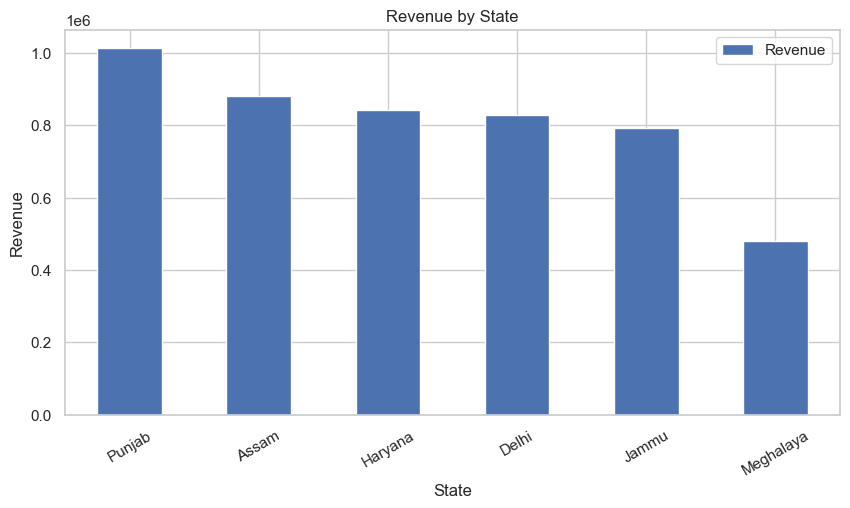

In [16]:
state_analysis.plot(
    x="State",
    y="Revenue",
    kind="bar",
    figsize=(10,5),
    title="Revenue by State"
)

plt.xlabel("State")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.show()

5. Which products are the real revenue stars?

In [17]:
query = """
SELECT
    p.Product_Name,
    p.Category,
    SUM(s.Quantity) AS Units_Sold,
    SUM(s.Net_Sales) AS Revenue,
    SUM(s.Profit) AS Profit
FROM Sales_Transactions s
JOIN Product_Master p
    ON s.Product_ID = p.Product_ID
GROUP BY
    p.Product_Name,
    p.Category
ORDER BY Revenue DESC
LIMIT 10;
"""

top_products = pd.read_sql(query, con=engine)
top_products

,Product_Name,Category,Units_Sold,Revenue,Profit
0,Frido CleanAir 90,Chimney,46.0,876756.16,333956.16
1,Frido PureAir 90,Chimney,32.0,528090.66,182490.66
2,Frido PureAir 60,Chimney,34.0,475168.32,169168.32
3,Frido AirFlow 90,Chimney,31.0,412410.54,145810.54
4,Frido Flame 4B,Gas Stove,71.0,395454.08,129204.08
5,Frido Spark Auto,Gas Stove,45.0,320132.31,108632.31
6,Frido CleanAir 60,Chimney,19.0,304962.06,113062.06
7,Frido Nano Cook,Gas Stove,63.0,234181.44,76681.44
8,Frido Flame 2B,Gas Stove,55.0,177364.31,56364.31
9,Frido HeatX 1600W,Induction,69.0,162709.89,59209.89


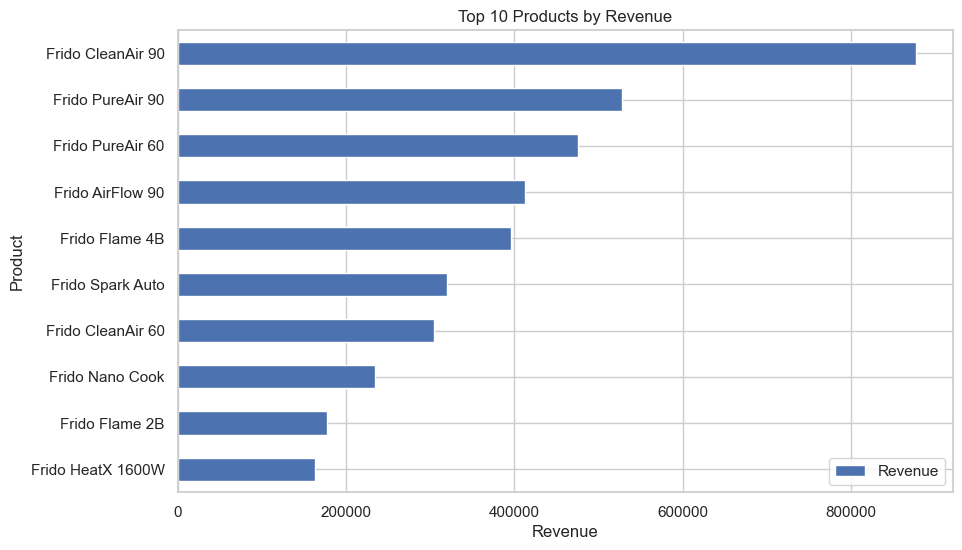

In [18]:
top_products.sort_values("Revenue").plot(
    x="Product_Name",
    y="Revenue",
    kind="barh",
    figsize=(10,6),
    title="Top 10 Products by Revenue"
)

plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()

6. Which products sell well but with the poor margin?

In [19]:
query = """
SELECT
    p.Product_Name,
    p.Category,
    SUM(s.Net_Sales) AS Revenue,
    SUM(s.Profit) AS Profit,
    ROUND(
        SUM(s.Profit) / SUM(s.Net_Sales) * 100,
        2
    ) AS Profit_Margin
FROM Sales_Transactions s
JOIN Product_Master p
    ON s.Product_ID = p.Product_ID
GROUP BY
    p.Product_Name,
    p.Category
HAVING Revenue > 100000
ORDER BY Profit_Margin ASC;
"""

margin_analysis = pd.read_sql(query, con=engine)
margin_analysis

,Product_Name,Category,Revenue,Profit,Profit_Margin
0,Frido Flame 2B,Gas Stove,177364.31,56364.31,31.78
1,Frido AirFlow 60,Chimney,150026.36,48026.36,32.01
2,Frido Flame 3B,Gas Stove,101047.54,32647.54,32.31
3,Frido Flame 4B,Gas Stove,395454.08,129204.08,32.67
4,Frido Nano Cook,Gas Stove,234181.44,76681.44,32.74
5,Frido RiceMate Pro 5L,Rice Cooker,132823.43,44623.43,33.60
6,Frido Spark Auto,Gas Stove,320132.31,108632.31,33.93
7,Frido PureAir 90,Chimney,528090.66,182490.66,34.56
8,Frido AirFlow 90,Chimney,412410.54,145810.54,35.36
9,Frido HeatX Pro 2000W,Induction,104270.20,37070.20,35.55


7. Which states and categories work best together?

In [20]:
query = """
SELECT
    c.State,
    s.Category,
    SUM(s.Net_Sales) AS Revenue
FROM Sales_Transactions s
JOIN Customer_Master c
    ON s.Customer_ID = c.Customer_ID
GROUP BY
    c.State,
    s.Category
ORDER BY
    c.State,
    Revenue DESC;
"""

state_category = pd.read_sql(query, con=engine)
state_category

,State,Category,Revenue
0,Assam,Chimney,515711.78
1,Assam,Gas Stove,233095.06
2,Assam,Rice Cooker,65436.91
3,Assam,Induction,46332.26
4,Assam,Tea Kettle,19300.86
5,Delhi,Chimney,377675.64
6,Delhi,Gas Stove,282422.76
7,Delhi,Induction,93604.10
8,Delhi,Rice Cooker,51596.36
9,Delhi,Tea Kettle,21875.40


8. Are discounts helping sales or hurting profitability?

In [21]:
query = """
SELECT
    CASE
        WHEN Discount_Pct = 0 THEN 'No Discount'
        WHEN Discount_Pct <= 0.10 THEN 'Low Discount'
        WHEN Discount_Pct <= 0.20 THEN 'Medium Discount'
        ELSE 'High Discount'
    END AS Discount_Level,

    SUM(Quantity) AS Units_Sold,
    SUM(Net_Sales) AS Revenue,
    SUM(Profit) AS Profit,

    ROUND(
        SUM(Profit) / SUM(Net_Sales) * 100,
        2
    ) AS Profit_Margin

FROM Sales_Transactions

GROUP BY Discount_Level

ORDER BY Revenue DESC;
"""

discount_analysis = pd.read_sql(query, con=engine)
discount_analysis

,Discount_Level,Units_Sold,Revenue,Profit,Profit_Margin
0,Low Discount,491.0,3538948.64,1264058.64,35.72
1,Medium Discount,154.0,774000.48,239620.48,30.96
2,No Discount,141.0,520059.00,200499.00,38.55


9.Which vendors are contributing most to the sales?

In [22]:
query = """
SELECT
    v.Vendor_Name,
    v.State,
    SUM(s.Net_Sales) AS Revenue,
    SUM(s.Profit) AS Profit,
    SUM(s.Quantity) AS Units_Sold,
    ROUND(
        SUM(s.Profit) / SUM(s.Net_Sales) * 100,
        2
    ) AS Profit_Margin

FROM Sales_Transactions s

JOIN Vendor_Master v
    ON s.Vendor_ID = v.Vendor_ID

GROUP BY
    v.Vendor_Name,
    v.State

ORDER BY Revenue DESC;
"""

vendor_analysis = pd.read_sql(query, con=engine)
vendor_analysis

,Vendor_Name,State,Revenue,Profit,Units_Sold,Profit_Margin
0,Apex Home Distributors,Delhi,600645.46,217395.46,74.0,36.19
1,SmartHome Distribution,Jammu,598892.69,220372.69,106.0,36.80
2,Shree Balaji Distributors,Assam,531687.77,188977.77,61.0,35.54
3,KitchenKart Distributors,Punjab,524541.95,184091.95,92.0,35.10
4,Royal Kitchen Supplies,Meghalaya,473335.33,157365.33,70.0,33.25
5,HomeTech Distributors,Jammu,428699.42,151599.42,63.0,35.36
6,Comfort Kitchen Traders,Meghalaya,427802.85,153842.85,64.0,35.96
7,Urban Home Appliances,Punjab,344852.88,118452.88,61.0,34.35
8,Prime Kitchen Dealers,Haryana,282851.26,97951.26,42.0,34.63
9,Capital Appliance Hub,Delhi,265622.44,89542.44,71.0,33.71


10. Which product have invventory risk?

In [23]:
query = """
SELECT
    p.Product_Name,
    SUM(i.Units_Sold) AS Units_Sold,
    SUM(i.Closing_Stock) AS Closing_Stock,

    ROUND(
        SUM(i.Units_Sold) /
        NULLIF(SUM(i.Closing_Stock), 0),
        2
    ) AS Stock_Turnover

FROM Inventory i

JOIN Product_Master p
    ON i.Product_ID = p.Product_ID

GROUP BY p.Product_Name

ORDER BY Stock_Turnover DESC;
"""

inventory_analysis = pd.read_sql(query, con=engine)
inventory_analysis

,Product_Name,Units_Sold,Closing_Stock,Stock_Turnover
0,Frido AirFlow 90,248.0,581.0,0.43
1,Frido PureAir 90,177.0,492.0,0.36
2,Frido Nano Cook,418.0,1265.0,0.33
3,Frido Flame 3B,394.0,1235.0,0.32
4,Frido TeaMate 2L,225.0,715.0,0.31
5,Frido RiceMate Pro 5L,340.0,1093.0,0.31
6,Frido CleanAir 90,326.0,1146.0,0.28
7,Frido CleanAir 60,203.0,727.0,0.28
8,Frido RiceMate 2.8L,78.0,285.0,0.27
9,Frido RiceMate 1.8L,284.0,1107.0,0.26


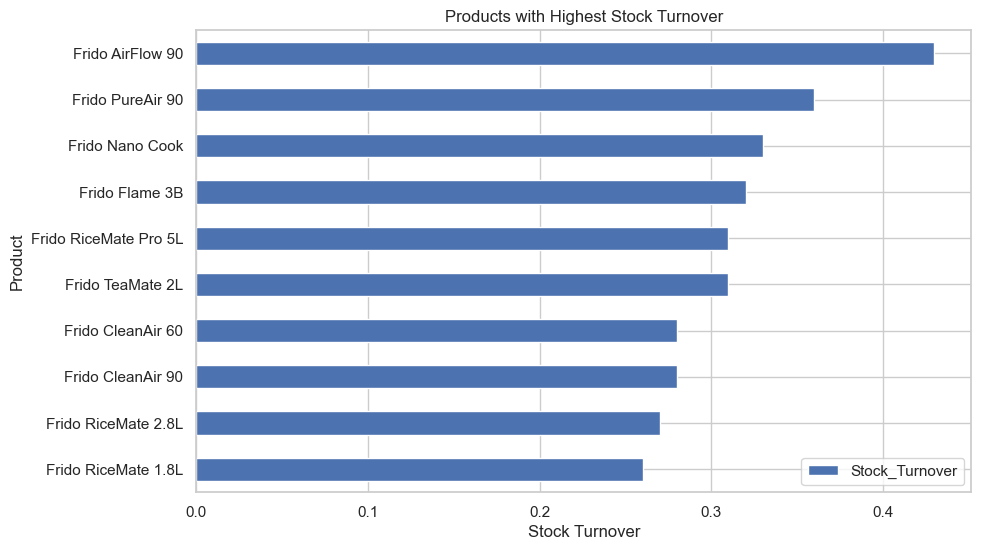

In [24]:
inventory_analysis.head(10).sort_values(
    "Stock_Turnover"
).plot(
    x="Product_Name",
    y="Stock_Turnover",
    kind="barh",
    figsize=(10,6),
    title="Products with Highest Stock Turnover"
)

plt.xlabel("Stock Turnover")
plt.ylabel("Product")
plt.show()